# Insurance Premium Regression

**Author:** Tajamul Khan  
**Task:** Regression  
**Primary metric:** MAE

## Project introduction

Estimate medical insurance charges from demographic, health and utilisation features.

This notebook is designed as a reproducible learning project: it keeps the final holdout untouched, fits every preprocessing step inside a Scikit-learn pipeline, and calculates all reported results from the available data.

## 1. Imports and reproducibility

A fixed seed makes the split and compatible estimators reproducible.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer, make_column_selector as selector
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.inspection import permutation_importance
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay, PrecisionRecallDisplay, RocCurveDisplay,
    accuracy_score, classification_report, f1_score,
    mean_absolute_error, mean_squared_error, r2_score,
)
from sklearn.model_selection import KFold, StratifiedKFold, TimeSeriesSplit, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import (
    AdaBoostClassifier, AdaBoostRegressor,
    GradientBoostingRegressor,
    RandomForestClassifier, RandomForestRegressor,
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)
CLASS_WEIGHT = None

## 2. Load the dataset

Paths are project-relative. If the dataset is not committed, the error message points to the recorded source and exact expected filename.

In [2]:
DATA_FILE = 'new_insurance_dataset.csv'
PROJECT_FOLDER = 'Insurance Premium Prediction using Regression Algorithms'
DATA_SOURCE = 'Dataset file is included in this project.'

def resolve_data_path(filename):
    candidates = [
        Path.cwd() / filename,
        Path.cwd() / "Supervised Learning Projects" / PROJECT_FOLDER / filename,
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"{filename} was not found. Place it beside the notebook. Dataset information: {DATA_SOURCE}"
    )

DATA_PATH = resolve_data_path(DATA_FILE)
raw = pd.read_csv(DATA_PATH, sep=',', low_memory=False)
print(f"Loaded {DATA_PATH.name}: {raw.shape[0]:,} rows × {raw.shape[1]} columns")

Loaded new_insurance_dataset.csv: 1,338 rows × 13 columns


## 3. Data cleaning

The cleaning function removes only documented identifiers, normalises missing-value markers, and leaves all trainable transformations to the pipeline.

In [3]:
def prepare_frame(frame):
    data = frame.copy()
    data.columns = data.columns.astype(str).str.strip()
    data = data.replace({"?": np.nan, "_": np.nan, "": np.nan, "NA": np.nan, "N/A": np.nan})
    data = data.drop_duplicates().reset_index(drop=True)
    return data.reset_index(drop=True)

data = prepare_frame(raw)
data.head()

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
0,18.0,male,23.21,0.0,no,29087.54313,17.0,715428.0,4720920.992,0.0,55784970.05,southeast,1121.8739
1,18.0,male,30.14,0.0,no,39053.67437,7.0,699157.0,4329831.676,0.0,13700885.19,southeast,1131.5066
2,18.0,male,33.33,0.0,no,39023.62759,19.0,702341.0,6884860.774,0.0,73523107.27,southeast,1135.9407
3,18.0,male,33.66,0.0,no,28185.39332,11.0,700250.0,4274773.550,0.0,75819679.60,southeast,1136.3994
4,18.0,male,34.10,0.0,no,14697.85941,16.0,711584.0,3787293.921,0.0,23012320.01,southeast,1137.0110


## 4. Data understanding and focused EDA

Inspect shape, types, missingness, duplicates and the target before modelling.

In [4]:
overview = pd.DataFrame({
    "dtype": data.dtypes.astype(str),
    "missing": data.isna().sum(),
    "missing_%": (data.isna().mean() * 100).round(2),
    "unique": data.nunique(dropna=False),
})
display(data.head())
display(overview.sort_values("missing", ascending=False).head(15))
print(f"Rows: {len(data):,} | Columns: {data.shape[1]} | Duplicate rows: {data.duplicated().sum():,}")

Rows: 1,338 | Columns: 13 | Duplicate rows: 0


,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
0,18.0,male,23.21,0.0,no,29087.54313,17.0,715428.0,4720920.992,0.0,55784970.05,southeast,1121.8739
1,18.0,male,30.14,0.0,no,39053.67437,7.0,699157.0,4329831.676,0.0,13700885.19,southeast,1131.5066
2,18.0,male,33.33,0.0,no,39023.62759,19.0,702341.0,6884860.774,0.0,73523107.27,southeast,1135.9407
3,18.0,male,33.66,0.0,no,28185.39332,11.0,700250.0,4274773.550,0.0,75819679.60,southeast,1136.3994
4,18.0,male,34.10,0.0,no,14697.85941,16.0,711584.0,3787293.921,0.0,23012320.01,southeast,1137.0110


,dtype,missing,missing_%,unique
Claim_Amount,float64,14,1.05,1325
age,float64,9,0.67,48
past_consultations,float64,6,0.45,40
Anual_Salary,float64,6,0.45,1333
children,float64,5,0.37,7
Hospital_expenditure,float64,4,0.30,1335
num_of_steps,float64,3,0.22,1336
bmi,float64,3,0.22,548
NUmber_of_past_hospitalizations,float64,2,0.15,5
smoker,object,0,0.00,2


,count,mean,std,min,25%,50%,75%,max
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


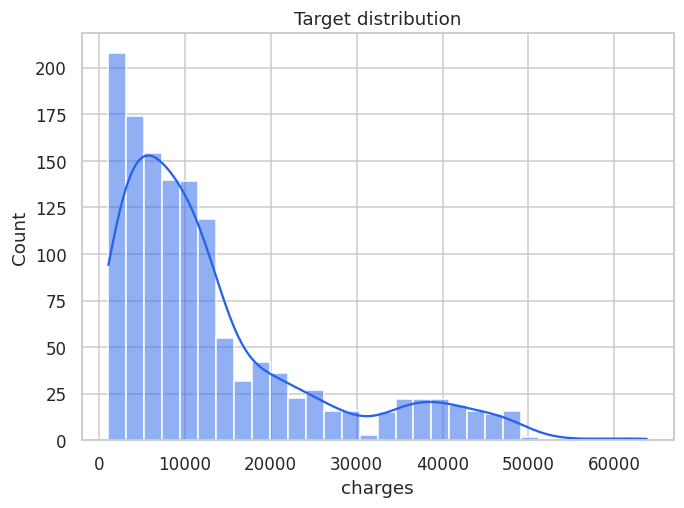

In [5]:
sns.histplot(data=data, x='charges', kde=True, color="#2563eb")
plt.title("Target distribution")
plt.tight_layout()
plt.show()
display(data['charges'].describe().to_frame().T)

## 5. Train/holdout strategy

The holdout is created before any imputer, scaler or encoder is fitted.

In [6]:
data = data.dropna(subset=['charges']).copy()
X = data.drop(columns='charges')
y = data['charges']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=None
)
print(f"Training rows: {len(X_train):,} | Holdout rows: {len(X_test):,}")

Training rows: 1,070 | Holdout rows: 268


## 6. Leakage-safe preprocessing

Numeric columns are median-imputed and scaled. Categorical columns are imputed and one-hot encoded with unknown-category handling.

In [7]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", min_frequency=2)),
])
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, selector(dtype_include=np.number)),
    ("categorical", categorical_pipeline, selector(dtype_exclude=np.number)),
])

## 7. Baseline and model comparison

Cross-validation is performed only on the training partition. The dummy baseline establishes whether the learned models add useful signal.

In [8]:
CLASS_WEIGHT = None
baseline = DummyRegressor(strategy='median')
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=180, min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=150, learning_rate=0.05, random_state=RANDOM_STATE),
}
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

rows = []
for name, estimator in {"Dummy baseline": baseline, **models}.items():
    candidate = Pipeline([("preprocessor", preprocessor), ("model", estimator)])
    scores = cross_validate(candidate, X_train, y_train, cv=cv, scoring="neg_mean_absolute_error", n_jobs=-1, error_score="raise")
    rows.append({"Model": name, 'CV MAE': -scores['test_score'].mean(), "CV std": scores["test_score"].std()})

comparison = pd.DataFrame(rows).sort_values('CV MAE', ascending=True).reset_index(drop=True)
display(comparison.round(4))

eligible = comparison[comparison["Model"] != "Dummy baseline"]
best_name = eligible.iloc[0]["Model"]
best_pipeline = Pipeline([("preprocessor", preprocessor), ("model", models[best_name])])
best_pipeline.fit(X_train, y_train)
print(f"Selected model: {best_name}")

Selected model: Random Forest


,Model,CV MAE,CV std
0,Random Forest,438.0576,34.5502
1,Gradient Boosting,502.0033,36.4839
2,Linear Regression,1002.5771,37.1491
3,Dummy baseline,8276.2769,139.8439


## 8. Holdout evaluation

These metrics are calculated once, after model selection, on data the pipeline has not seen.

,Metric,Holdout value
0,MAE,461.6722
1,RMSE,1336.3642
2,R²,0.9888


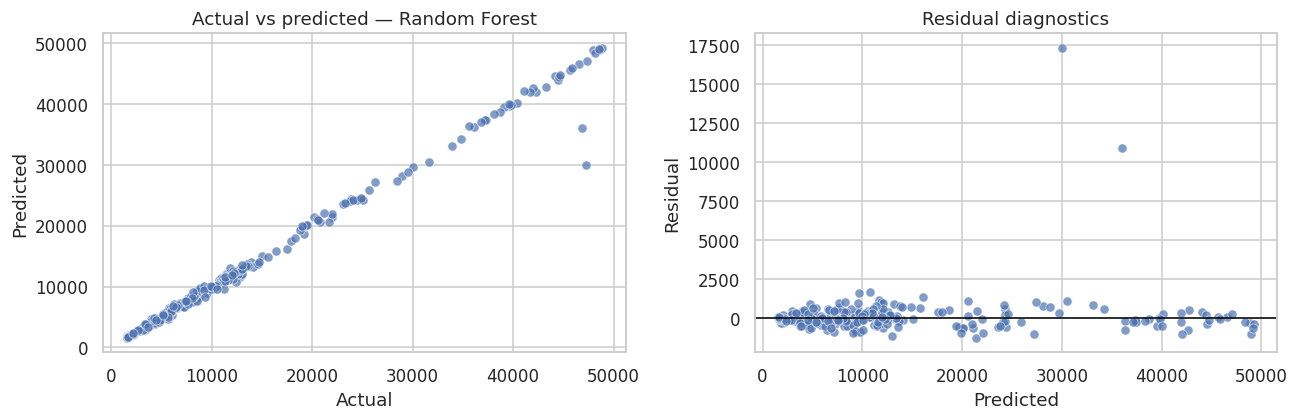

In [9]:
predictions = best_pipeline.predict(X_test)
mae = mean_absolute_error(y_test, predictions)
rmse = mean_squared_error(y_test, predictions) ** 0.5
r2 = r2_score(y_test, predictions)
display(pd.DataFrame({"Metric": ["MAE", "RMSE", "R²"], "Holdout value": [mae, rmse, r2]}).round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.scatterplot(x=y_test, y=predictions, ax=axes[0], alpha=0.7)
axes[0].set(xlabel="Actual", ylabel="Predicted", title=f"Actual vs predicted — {best_name}")
residuals = y_test - predictions
sns.scatterplot(x=predictions, y=residuals, ax=axes[1], alpha=0.7)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set(xlabel="Predicted", ylabel="Residual", title="Residual diagnostics")
plt.tight_layout()
plt.show()

## 9. Model interpretation

Permutation importance measures the holdout-score change when each original feature is shuffled. It works across mixed numeric and categorical pipelines.

,feature,importance_mean,importance_std
7,num_of_steps,4562.9137,152.1565
9,NUmber_of_past_hospitalizations,2956.4222,185.5420
10,Anual_Salary,2577.9802,100.7260
8,Hospital_expenditure,606.9047,22.5136
0,age,232.3436,22.3405
3,children,17.1447,2.5727
4,smoker,4.5563,2.8649
2,bmi,4.1303,1.8397
11,region,2.2302,1.8724
1,sex,1.7644,1.3863


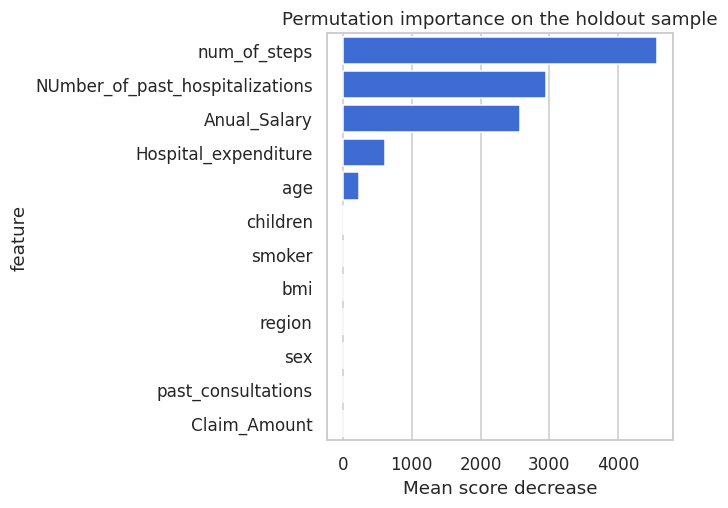

In [10]:
sample_size = min(2000, len(X_test))
X_importance = X_test.sample(sample_size, random_state=RANDOM_STATE)
y_importance = y_test.loc[X_importance.index]
importance = permutation_importance(
    best_pipeline, X_importance, y_importance,
    scoring='neg_mean_absolute_error', n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1,
)
importance_df = pd.DataFrame({
    "feature": X_importance.columns,
    "importance_mean": importance.importances_mean,
    "importance_std": importance.importances_std,
}).sort_values("importance_mean", ascending=False).head(15)
display(importance_df.round(4))
sns.barplot(data=importance_df, x="importance_mean", y="feature", color="#2563eb")
plt.title("Permutation importance on the holdout sample")
plt.xlabel("Mean score decrease")
plt.tight_layout()
plt.show()

## 10. Key findings and next steps

- Read the model-comparison table relative to the dummy baseline, not in isolation.
- Use the holdout confusion matrix or residual plot to identify the most costly errors.
- Treat permutation importance as model-specific evidence, not causation.
- Before deployment, validate on a newer or independently collected dataset and monitor data drift.

All numeric results in this notebook are generated from the dataset at execution time; none are hard-coded.